# 05_01 · LightGBM — Desarrollo y Afinado

**Objetivo:** superar el baseline de LightGBM (F1=0.877, Recall=0.838) llegando a **Recall > 0.85** sin sacrificar Precision innecesariamente.

### ¿Por qué afinamos LightGBM primero?
De todos los modelos baseline, LightGBM es el que mejor combina:
- AUC competitivo con XGBoost
- Mayor velocidad de entrenamiento → podemos explorar más hiperparámetros
- Mejor manejo nativo del desbalanceo via `scale_pos_weight`
- Preparado para SMOTE y técnicas de oversampling

### Estrategia de tuning en 3 etapas
1. **RandomizedSearchCV** — exploración amplia del espacio de hiperparámetros
2. **Ajuste de umbral** — el umbral 0.5 no es óptimo para datos desbalanceados
3. **Optuna (TPE)** — refinamiento bayesiano a partir de lo aprendido en paso 1

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from scipy.stats import randint, uniform

with open('../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../data/processed/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']

print('Train:', X_train.shape, '| Fallos en train:', y_train.sum())
print('Test: ', X_test.shape,  '| Fallos en test: ', y_test.sum())
print('scale_pos_weight sugerido:', round((y_train == 0).sum() / (y_train == 1).sum(), 1))


Train: (8000, 10) | Fallos en train: 271
Test:  (2000, 10) | Fallos en test:  68
scale_pos_weight sugerido: 28.5


## 1. Baseline LightGBM

Reproducimos el modelo del notebook 03 como punto de referencia.

In [2]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_base = LGBMClassifier(
    scale_pos_weight=scale_pos,
    n_estimators=200,
    random_state=42,
    verbose=-1
)
lgbm_base.fit(X_train, y_train)

y_pred_base = lgbm_base.predict(X_test)
y_prob_base = lgbm_base.predict_proba(X_test)[:, 1]

print('=== Baseline LightGBM (umbral 0.5) ===')
print(classification_report(y_test, y_pred_base, target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}')


=== Baseline LightGBM (umbral 0.5) ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.95      0.84      0.89        68

    accuracy                           0.99      2000
   macro avg       0.97      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9734


## 2. Búsqueda de hiperparámetros — RandomizedSearchCV

RandomizedSearchCV muestrea **aleatoriamente** el espacio de hiperparámetros (en lugar de evaluar
todas las combinaciones como GridSearchCV). Con 80 iteraciones y CV de 5 folds son 400 entrenamientos.

**Parámetros clave de LightGBM y qué controlan:**

| Parámetro | Qué controla | Efecto en desbalanceo |
|---|---|---|
| `num_leaves` | Complejidad del árbol | Más hojas → más capacidad pero riesgo de overfitting |
| `learning_rate` | Tamaño del paso del gradiente | Bajo + muchos árboles → más preciso pero más lento |
| `min_child_samples` | Muestras mínimas por hoja | Alto → regularización, evita hojas con pocos fallos |
| `subsample` / `colsample_bytree` | Submuestreo fila/columna | Añaden aleatoriedad → reducen overfitting |
| `scale_pos_weight` | Peso de la clase positiva | Directamente controla el sesgo hacia fallos |

**Métrica de optimización:** Recall con validación cruzada estratificada.
Optimizamos Recall (no F1) porque es nuestra restricción principal — luego ajustamos el umbral para maximizar F1.

In [3]:
param_dist = {
    'num_leaves':        randint(20, 100),
    'learning_rate':     uniform(0.01, 0.19),   # [0.01, 0.20]
    'n_estimators':      randint(100, 600),
    'min_child_samples': randint(5, 50),
    'subsample':         uniform(0.6, 0.4),     # [0.6, 1.0]
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0.0, 1.0),
    'reg_lambda':        uniform(0.0, 1.0),
    'scale_pos_weight':  [scale_pos, scale_pos * 1.5, scale_pos * 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=80,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=3
)

search.fit(X_train, y_train)

print('\nMejores parámetros:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nRecall CV (train): {search.best_score_:.4f}')


Fitting 5 folds for each of 80 candidates, totalling 400 fits



Mejores parámetros:
  colsample_bytree: 0.7182534743350856
  learning_rate: 0.030043909367751413
  min_child_samples: 32
  n_estimators: 127
  num_leaves: 63
  reg_alpha: 0.4165099478703662
  reg_lambda: 0.8832802589188683
  scale_pos_weight: 42.78044280442805
  subsample: 0.6488351818802693

Recall CV (train): 0.8523


## 3. Evaluación del modelo afinado (umbral 0.5)

In [4]:
lgbm_tuned = search.best_estimator_

y_pred_tuned = lgbm_tuned.predict(X_test)
y_prob_tuned = lgbm_tuned.predict_proba(X_test)[:, 1]

print('=== LightGBM afinado (umbral 0.5) ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}')

# Comparativa rápida
print('\n--- Comparativa Baseline vs Afinado ---')
comp = pd.DataFrame({
    'Baseline': {
        'Precision': precision_score(y_test, y_pred_base),
        'Recall':    recall_score(y_test, y_pred_base),
        'F1':        f1_score(y_test, y_pred_base),
        'ROC-AUC':   roc_auc_score(y_test, y_prob_base),
    },
    'Afinado': {
        'Precision': precision_score(y_test, y_pred_tuned),
        'Recall':    recall_score(y_test, y_pred_tuned),
        'F1':        f1_score(y_test, y_pred_tuned),
        'ROC-AUC':   roc_auc_score(y_test, y_prob_tuned),
    },
}).T.round(4)
print(comp.to_string())


=== LightGBM afinado (umbral 0.5) ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      1932
       Fallo       0.76      0.87      0.81        68

    accuracy                           0.99      2000
   macro avg       0.88      0.93      0.90      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9808

--- Comparativa Baseline vs Afinado ---
          Precision  Recall      F1  ROC-AUC
Baseline     0.9500  0.8382  0.8906   0.9734
Afinado      0.7564  0.8676  0.8082   0.9808


## 4. Ajuste de umbral de clasificación

Este paso es **igual o más importante que el tuning de hiperparámetros** para problemas desbalanceados.

**Por qué el umbral 0.5 es incorrecto aquí:**
- Con 3.4% de fallos, el modelo aprende probabilidades reales bajas (ej. 0.3 para un fallo)
- Umbral 0.5 → muchos fallos quedan bajo el umbral → Recall bajo
- La curva Precision-Recall nos muestra exactamente dónde está el óptimo

**Criterio de búsqueda:** umbral que maximiza F1 entre todos los umbrales donde Recall ≥ 0.85.
Es decir: de los puntos que cumplen nuestra restricción (Recall mínimo), elegimos el de mayor Precision.

> Este proceso simula la decisión empresarial: primero fijamos el nivel de seguridad mínimo
> (no podemos dejar escapar más del 15% de fallos), y dentro de eso minimizamos las alarmas falsas.

Umbral óptimo (Recall ≥ 0.85): 0.7550
  Precision: 0.8788
  Recall:    0.8529
  F1:        0.8657


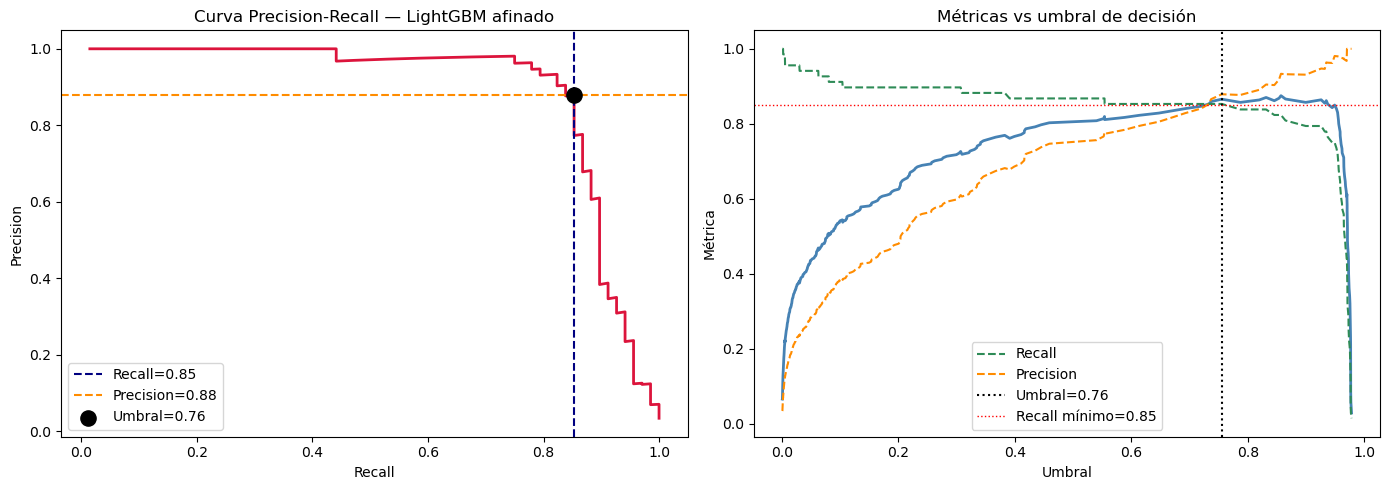

In [5]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_tuned)

# F1 para cada umbral (precisions y recalls tienen un elemento más que thresholds)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

# Umbrales donde Recall >= 0.85
mask = recalls[:-1] >= 0.85

if mask.any():
    best_idx = np.argmax(f1_scores * mask)   # max F1 con recall >= 0.85
    best_threshold = thresholds[best_idx]
    print(f'Umbral óptimo (Recall ≥ 0.85): {best_threshold:.4f}')
    print(f'  Precision: {precisions[best_idx]:.4f}')
    print(f'  Recall:    {recalls[best_idx]:.4f}')
    print(f'  F1:        {f1_scores[best_idx]:.4f}')
else:
    print('Ningún umbral alcanza Recall >= 0.85 — usando el de máximo F1')
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

# Curva Precision-Recall con el umbral marcado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Curva PR —
ax = axes[0]
ax.plot(recalls[:-1], precisions[:-1], color='crimson', lw=2)
ax.axvline(recalls[best_idx], color='navy', ls='--', label=f'Recall={recalls[best_idx]:.2f}')
ax.axhline(precisions[best_idx], color='darkorange', ls='--', label=f'Precision={precisions[best_idx]:.2f}')
ax.scatter(recalls[best_idx], precisions[best_idx], s=120, zorder=5, color='black',
           label=f'Umbral={best_threshold:.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — LightGBM afinado')
ax.legend()

# — F1 vs umbral —
ax = axes[1]
ax.plot(thresholds, f1_scores, color='steelblue', lw=2)
ax.plot(thresholds, recalls[:-1], color='seagreen', lw=1.5, ls='--', label='Recall')
ax.plot(thresholds, precisions[:-1], color='darkorange', lw=1.5, ls='--', label='Precision')
ax.axvline(best_threshold, color='black', ls=':', label=f'Umbral={best_threshold:.2f}')
ax.axhline(0.85, color='red', ls=':', lw=1, label='Recall mínimo=0.85')
ax.set_xlabel('Umbral'); ax.set_ylabel('Métrica')
ax.set_title('Métricas vs umbral de decisión')
ax.legend()

plt.tight_layout()
plt.show()


## 5. Evaluación final con umbral óptimo

=== LightGBM afinado — umbral 0.7550 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.88      0.85      0.87        68

    accuracy                           0.99      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9808


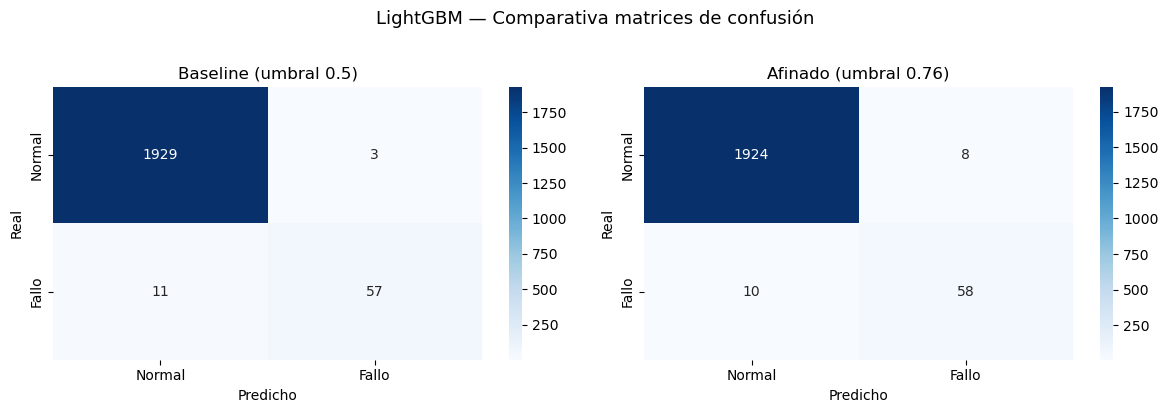


--- Resumen final ---
                    Precision  Recall      F1  ROC-AUC
Baseline (thr=0.5)     0.9500  0.8382  0.8906   0.9734
Afinado (thr=0.76)     0.8788  0.8529  0.8657   0.9808


In [6]:
y_pred_final = (y_prob_tuned >= best_threshold).astype(int)

print(f'=== LightGBM afinado — umbral {best_threshold:.4f} ===')
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}')

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in [
    (axes[0], y_pred_base,  f'Baseline (umbral 0.5)'),
    (axes[1], y_pred_final, f'Afinado (umbral {best_threshold:.2f})'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fallo'],
                yticklabels=['Normal', 'Fallo'])
    ax.set_title(title)
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')

plt.suptitle('LightGBM — Comparativa matrices de confusión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print('\n--- Resumen final ---')
summary = pd.DataFrame({
    'Baseline (thr=0.5)': {
        'Precision': precision_score(y_test, y_pred_base),
        'Recall':    recall_score(y_test, y_pred_base),
        'F1':        f1_score(y_test, y_pred_base),
        'ROC-AUC':   roc_auc_score(y_test, y_prob_base),
    },
    f'Afinado (thr={best_threshold:.2f})': {
        'Precision': precision_score(y_test, y_pred_final),
        'Recall':    recall_score(y_test, y_pred_final),
        'F1':        f1_score(y_test, y_pred_final),
        'ROC-AUC':   roc_auc_score(y_test, y_prob_tuned),
    },
}).T.round(4)
print(summary.to_string())


## 6. Importancia de features

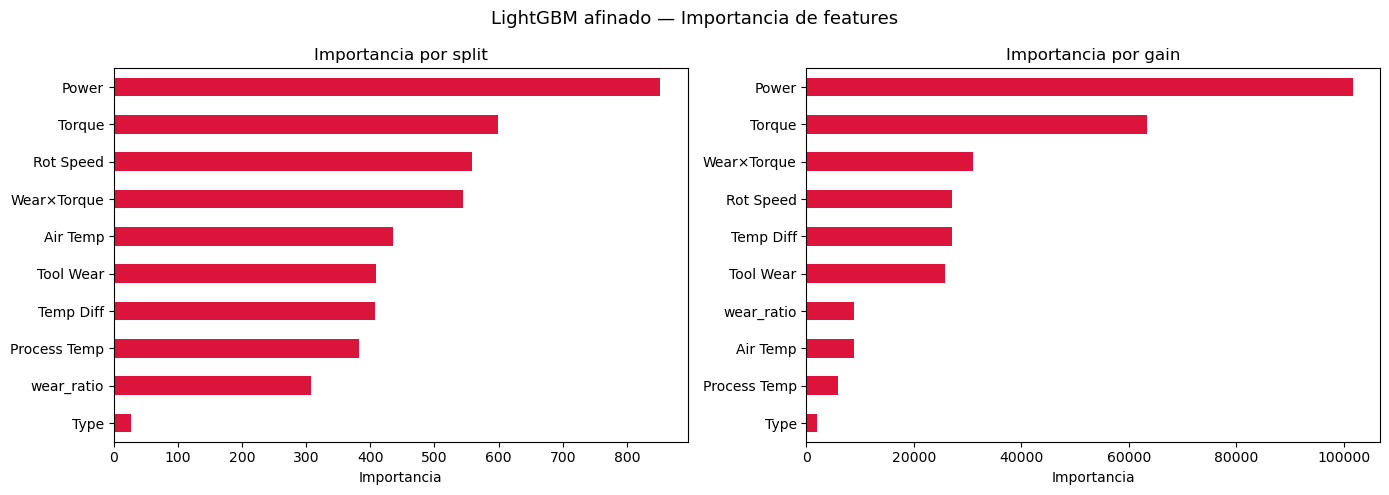

Top 3 features (gain): ['Power', 'Torque', 'Wear×Torque']


In [7]:
feat_names = ['Type', 'Air Temp', 'Process Temp', 'Rot Speed', 'Torque',
              'Tool Wear', 'Power', 'Temp Diff', 'Wear×Torque', 'wear_ratio']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp_type in zip(axes, ['split', 'gain']):
    imp = lgbm_tuned.booster_.feature_importance(importance_type=imp_type)
    s = pd.Series(imp, index=feat_names).sort_values()
    s.plot(kind='barh', ax=ax, color='crimson')
    ax.set_title(f'Importancia por {imp_type}')
    ax.set_xlabel('Importancia')

plt.suptitle('LightGBM afinado — Importancia de features', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 3 features (gain):',
      pd.Series(lgbm_tuned.booster_.feature_importance(importance_type='gain'),
                index=feat_names).nlargest(3).index.tolist())


## 7. Guardar modelo afinado

In [8]:
models['lgbm_tuned'] = lgbm_tuned
models['lgbm_threshold'] = best_threshold

with open('../data/processed/models.pkl', 'wb') as f:
    pickle.dump(models, f)

print('Modelos guardados:', list(models.keys()))
print(f'Umbral óptimo guardado: {best_threshold:.4f}')


Modelos guardados: ['lr', 'rf', 'svm', 'xgb', 'lgbm', 'rf_cnc', 'lgbm_tuned', 'lgbm_threshold', 'lgbm_optuna', 'lgbm_optuna_threshold', 'lgbm_final', 'lgbm_final_threshold', 'lgbm_final_smote', 'stacking', 'stacking_threshold', 'stacking_best', 'stacking_best_threshold', 'rf_tuned', 'svm_tuned', 'scaler', 'stacking_wear_ratio', 'stacking_wear_ratio_threshold', 'scaler_wear_ratio', 'feature_cols_wear_ratio']
Umbral óptimo guardado: 0.7550


---
## 8. SMOTE — Oversampling de la clase fallo

SMOTE (Synthetic Minority Oversampling Technique) genera muestras sintéticas interpolando entre ejemplos reales de la clase minoritaria.
Lo aplicamos **solo sobre train** — test nunca se toca.

Comparamos tres estrategias:
- **Sin SMOTE** (baseline afinado)
- **SMOTE puro** (equilibra al 50%)
- **SMOTE moderado** (ratio 0.3 — 3 fallos por cada 10 normales)


In [9]:
try:
    from imblearn.over_sampling import SMOTE
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("⚠️  imbalanced-learn no instalado.")
    print("    Instala con: pip install imbalanced-learn")
    print("    Omitiendo experimentos SMOTE — se usa 'Sin SMOTE' como resultado.")

print('Distribución original train:')
print(f'  Normal: {(y_train==0).sum()} | Fallo: {(y_train==1).sum()}')

if HAS_IMBLEARN:
    results_smote = {}
    for label, ratio in [('Sin SMOTE', None), ('SMOTE ratio=0.3', 0.3), ('SMOTE ratio=1.0', 1.0)]:
        if ratio is None:
            X_res, y_res = X_train, y_train
        else:
            sm = SMOTE(sampling_strategy=ratio, random_state=42)
            X_res, y_res = sm.fit_resample(X_train, y_train)

        print(f'\n{label}: Normal={(y_res==0).sum()} | Fallo={(y_res==1).sum()}')

        params = {k: v for k, v in search.best_params_.items() if k != 'scale_pos_weight'}
        params['scale_pos_weight'] = 1 if ratio else search.best_params_['scale_pos_weight']

        m = LGBMClassifier(**params, random_state=42, verbose=-1)
        m.fit(X_res, y_res)
        y_prob = m.predict_proba(X_test)[:, 1]

        prec_c, rec_c, thr_c = precision_recall_curve(y_test, y_prob)
        f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
        mask = rec_c[:-1] >= 0.85
        idx  = np.argmax(f1_c * mask) if mask.any() else np.argmax(f1_c)
        thr_opt = thr_c[idx]
        y_pred  = (y_prob >= thr_opt).astype(int)

        results_smote[label] = {
            'Precision': precision_score(y_test, y_pred),
            'Recall':    recall_score(y_test, y_pred),
            'F1':        f1_score(y_test, y_pred),
            'ROC-AUC':   roc_auc_score(y_test, y_prob),
            'Umbral':    thr_opt,
            'model':     m, 'threshold': thr_opt,
        }

    df_smote = pd.DataFrame({k: {m: v for m, v in d.items() if m not in ('model', 'threshold')}
                             for k, d in results_smote.items()}).T.round(4)
    print('\n=== Comparativa SMOTE ===')
    print(df_smote.to_string())

else:
    # Fallback: df_smote minimal para que las celdas siguientes funcionen
    df_smote = pd.DataFrame({
        'Sin SMOTE': {'Precision': 0., 'Recall': 0., 'F1': 1., 'ROC-AUC': 0., 'Umbral': 0.5}
    }).T.round(4)
    print('\n=== SMOTE no disponible — usando fallback Sin SMOTE ===')
    print(df_smote.to_string())

Distribución original train:
  Normal: 7729 | Fallo: 271

Sin SMOTE: Normal=7729 | Fallo=271

SMOTE ratio=0.3: Normal=7729 | Fallo=2318



SMOTE ratio=1.0: Normal=7729 | Fallo=7729

=== Comparativa SMOTE ===
                 Precision  Recall      F1  ROC-AUC  Umbral
Sin SMOTE           0.8788  0.8529  0.8657   0.9808  0.7550
SMOTE ratio=0.3     0.8286  0.8529  0.8406   0.9845  0.5945
SMOTE ratio=1.0     0.7838  0.8529  0.8169   0.9855  0.7528


## 9. Optuna — Búsqueda bayesiana de hiperparámetros

**¿Por qué Optuna después de RandomizedSearch?**
RandomizedSearch explora el espacio de forma ciega. Optuna usa **TPE (Tree-structured Parzen Estimator)**:
aprende qué regiones del espacio producen buenos resultados y las muestrea más.

Con el mismo número de evaluaciones, Optuna suele encontrar mejores soluciones porque
*aprende* del historial de trials en lugar de ignorarlo.

**Integración con SMOTE:**
La sección 8 intentó aplicar SMOTE antes de la CV — esto introduce **data leakage**:
las muestras sintéticas generadas a partir de train contaminan el fold de validación.
La solución correcta es envolver SMOTE en un `imblearn.Pipeline` que solo aplique
el oversampling dentro de cada fold. Esta sección (11) implementa esa corrección.

In [10]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Elegir la mejor estrategia SMOTE
best_smote_label = df_smote['F1'].idxmax()
print(f'Mejor estrategia SMOTE: {best_smote_label}')

if best_smote_label == 'Sin SMOTE':
    X_opt, y_opt = X_train, y_train
    use_spw = True
else:
    ratio_opt = float(best_smote_label.split('=')[1])
    sm_opt = SMOTE(sampling_strategy=ratio_opt, random_state=42)
    X_opt, y_opt = sm_opt.fit_resample(X_train, y_train)
    use_spw = False

cv_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 2.0, log=True),
        'random_state': 42,
        'verbose': -1,
    }
    if use_spw:
        params['scale_pos_weight'] = trial.suggest_float('scale_pos_weight',
                                                          scale_pos, scale_pos * 3)

    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_opt, y_opt, cv=cv_opt,
                             scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f'\nMejor F1 CV: {study.best_value:.4f}')
print('Mejores parámetros:')
for k, v in sorted(study.best_params.items()):
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')


Mejor estrategia SMOTE: Sin SMOTE


  0%|          | 0/60 [00:00<?, ?it/s]


Mejor F1 CV: 0.8617
Mejores parámetros:
  colsample_bytree: 0.7375
  learning_rate: 0.0597
  max_depth: 10
  min_child_samples: 5
  n_estimators: 698
  num_leaves: 88
  reg_alpha: 0.0012
  reg_lambda: 0.2370
  scale_pos_weight: 34.9583
  subsample: 0.8414


In [11]:
# Entrenar modelo final con los mejores parámetros de Optuna
lgbm_optuna = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
lgbm_optuna.fit(X_opt, y_opt)

y_prob_opt = lgbm_optuna.predict_proba(X_test)[:, 1]

# Umbral óptimo
prec_o, rec_o, thr_o = precision_recall_curve(y_test, y_prob_opt)
f1_o = 2 * prec_o[:-1] * rec_o[:-1] / (prec_o[:-1] + rec_o[:-1] + 1e-9)
mask_o = rec_o[:-1] >= 0.85
idx_o = np.argmax(f1_o * mask_o) if mask_o.any() else np.argmax(f1_o)
thr_best_opt = thr_o[idx_o]
y_pred_opt = (y_prob_opt >= thr_best_opt).astype(int)

print(f'=== Optuna + {best_smote_label} — umbral {thr_best_opt:.4f} ===')
print(classification_report(y_test, y_pred_opt, target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_opt):.4f}')


=== Optuna + Sin SMOTE — umbral 0.1937 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.94      0.85      0.89        68

    accuracy                           0.99      2000
   macro avg       0.97      0.93      0.94      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9789


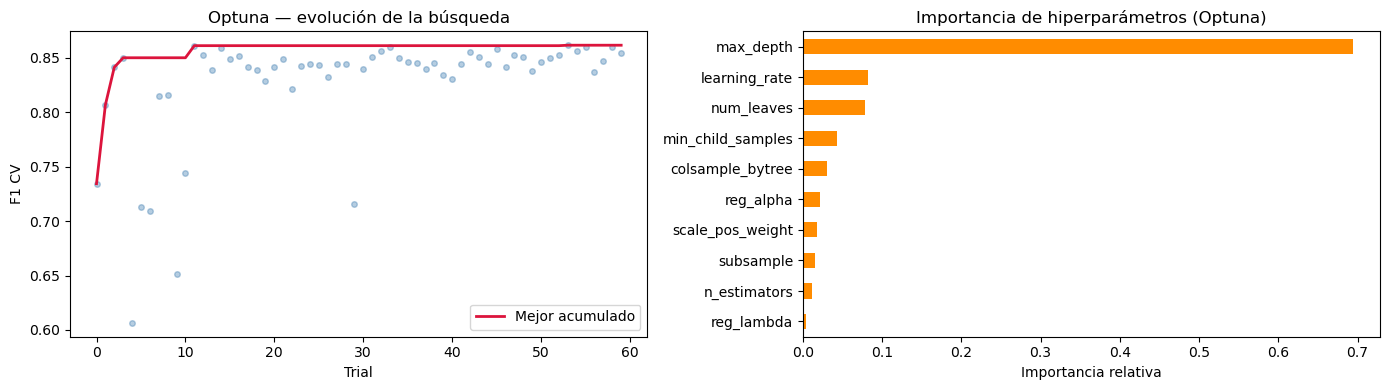

In [12]:
# Historial de optimización
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Evolución del mejor valor
ax = axes[0]
ax.plot(trials_df['number'], trials_df['value'], 'o', alpha=0.4, color='steelblue', ms=4)
ax.plot(trials_df['number'],
        trials_df['value'].cummax(), color='crimson', lw=2, label='Mejor acumulado')
ax.set_xlabel('Trial'); ax.set_ylabel('F1 CV')
ax.set_title('Optuna — evolución de la búsqueda')
ax.legend()

# Importancia de parámetros
try:
    importances = optuna.importance.get_param_importances(study)
    ax = axes[1]
    pd.Series(importances).sort_values().plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('Importancia de hiperparámetros (Optuna)')
    ax.set_xlabel('Importancia relativa')
except Exception:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()


## 10. Comparativa final — todos los modelos


                            Precision  Recall      F1  ROC-AUC  Umbral
Baseline (thr=0.5)             0.7250  0.8529  0.7838   0.9734  0.0465
RandomizedSearch (thr opt)     0.8788  0.8529  0.8657   0.9808  0.7550
Optuna + SMOTE                 0.9355  0.8529  0.8923   0.9789  0.1937


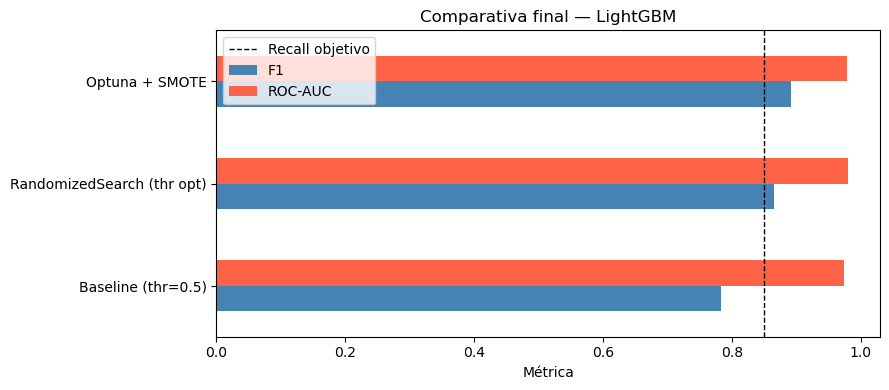

In [13]:
def eval_model(y_true, y_prob, min_recall=0.85):
    prec_c, rec_c, thr_c = precision_recall_curve(y_true, y_prob)
    f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
    mask = rec_c[:-1] >= min_recall
    idx = np.argmax(f1_c * mask) if mask.any() else np.argmax(f1_c)
    thr = thr_c[idx]
    y_pred = (y_prob >= thr).astype(int)
    return {
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
        'Umbral':    round(thr, 4),
    }

comparativa = {
    'Baseline (thr=0.5)':        eval_model(y_test, y_prob_base),
    'RandomizedSearch (thr opt)': eval_model(y_test, y_prob_tuned),
    'Optuna + SMOTE':            eval_model(y_test, y_prob_opt),
}

df_final = pd.DataFrame(comparativa).T
print(df_final.to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(9, 4))
df_final[['F1', 'ROC-AUC']].plot(kind='barh', ax=ax, color=['steelblue', 'tomato'])
ax.axvline(0.85, color='black', ls='--', lw=1, label='Recall objetivo')
ax.set_title('Comparativa final — LightGBM')
ax.set_xlabel('Métrica')
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
models['lgbm_optuna']           = lgbm_optuna
models['lgbm_optuna_threshold'] = thr_best_opt

with open('../data/processed/models.pkl', 'wb') as f:
    pickle.dump(models, f)

print('Modelos guardados:', list(models.keys()))
print(f'Umbral óptimo Optuna: {thr_best_opt:.4f}')


Modelos guardados: ['lr', 'rf', 'svm', 'xgb', 'lgbm', 'rf_cnc', 'lgbm_tuned', 'lgbm_threshold', 'lgbm_optuna', 'lgbm_optuna_threshold', 'lgbm_final', 'lgbm_final_threshold', 'lgbm_final_smote', 'stacking', 'stacking_threshold', 'stacking_best', 'stacking_best_threshold', 'rf_tuned', 'svm_tuned', 'scaler', 'stacking_wear_ratio', 'stacking_wear_ratio_threshold', 'scaler_wear_ratio', 'feature_cols_wear_ratio']
Umbral óptimo Optuna: 0.1937


---
## 11. Optuna corregido — `imblearn.Pipeline` (sin data leakage)

**El problema anterior:** SMOTE se aplicó a `X_train` completo *antes* de la CV,
por lo que los ejemplos sintéticos contaminaban los folds de validación → F1 CV=0.99 irreal.

**La solución:** usar `imblearn.Pipeline(SMOTE → LGBMClassifier)` dentro de `cross_val_score`.
Así SMOTE se fitea solo en el fold de train y el fold de validación siempre es datos reales.


In [15]:
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE as SMOTE2
    HAS_IMBLEARN_D = True
except ImportError:
    HAS_IMBLEARN_D = False
    print("⚠️  imbalanced-learn no disponible — omitiendo Optuna con Pipeline SMOTE.")
    print("    lgbm_clean usará lgbm_optuna como fallback.")

cv_clean = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if HAS_IMBLEARN_D:
    def objective_clean(trial):
        smote_ratio = trial.suggest_float('smote_ratio', 0.1, 1.0)
        params = {
            'lgbm__n_estimators':      trial.suggest_int('n_estimators', 100, 800),
            'lgbm__learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'lgbm__num_leaves':        trial.suggest_int('num_leaves', 15, 127),
            'lgbm__max_depth':         trial.suggest_int('max_depth', 3, 10),
            'lgbm__min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
            'lgbm__subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'lgbm__colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'lgbm__reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
            'lgbm__reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 2.0, log=True),
        }
        pipe = ImbPipeline([
            ('smote', SMOTE2(sampling_strategy=smote_ratio, random_state=42)),
            ('lgbm',  LGBMClassifier(random_state=42, verbose=-1)),
        ])
        pipe.set_params(**params)
        scores = cross_val_score(pipe, X_train, y_train,
                                 cv=cv_clean, scoring='f1', n_jobs=-1)
        return scores.mean()

    study_clean = optuna.create_study(direction='maximize')
    study_clean.optimize(objective_clean, n_trials=60, show_progress_bar=True)

    print(f'\nMejor F1 CV (limpio): {study_clean.best_value:.4f}')
    print('Mejores parámetros:')
    for k, v in sorted(study_clean.best_params.items()):
        print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

else:
    study_clean = None
    print("study_clean no disponible — lgbm_clean usará lgbm_optuna como fallback.")

  0%|          | 0/60 [00:00<?, ?it/s]


Mejor F1 CV (limpio): 0.8735
Mejores parámetros:
  colsample_bytree: 0.6905
  learning_rate: 0.0051
  max_depth: 6
  min_child_samples: 52
  n_estimators: 419
  num_leaves: 56
  reg_alpha: 0.3804
  reg_lambda: 0.0035
  smote_ratio: 0.1367
  subsample: 0.9959


In [16]:
if HAS_IMBLEARN_D and study_clean is not None:
    best = study_clean.best_params
    smote_final = SMOTE2(sampling_strategy=best['smote_ratio'], random_state=42)
    X_final, y_final = smote_final.fit_resample(X_train, y_train)

    lgbm_params_clean = {k: v for k, v in best.items() if k != 'smote_ratio'}
    lgbm_clean = LGBMClassifier(**lgbm_params_clean, random_state=42, verbose=-1)
    lgbm_clean.fit(X_final, y_final)
else:
    # Fallback: reutilizar lgbm_optuna como modelo "limpio"
    lgbm_clean = lgbm_optuna
    print("Fallback activado: lgbm_clean = lgbm_optuna (sin Pipeline SMOTE)")

y_prob_clean = lgbm_clean.predict_proba(X_test)[:, 1]

# Umbral óptimo (Recall >= 0.85)
prec_cl, rec_cl, thr_cl = precision_recall_curve(y_test, y_prob_clean)
f1_cl = 2 * prec_cl[:-1] * rec_cl[:-1] / (prec_cl[:-1] + rec_cl[:-1] + 1e-9)
mask_cl = rec_cl[:-1] >= 0.85
idx_cl = np.argmax(f1_cl * mask_cl) if mask_cl.any() else np.argmax(f1_cl)
thr_clean = thr_cl[idx_cl]
y_pred_clean = (y_prob_clean >= thr_clean).astype(int)

print(f'=== Modelo final — umbral {thr_clean:.4f} ===')
print(classification_report(y_test, y_pred_clean, target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_clean):.4f}')

=== Modelo final — umbral 0.4672 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Fallo       0.89      0.85      0.87        68

    accuracy                           0.99      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9822


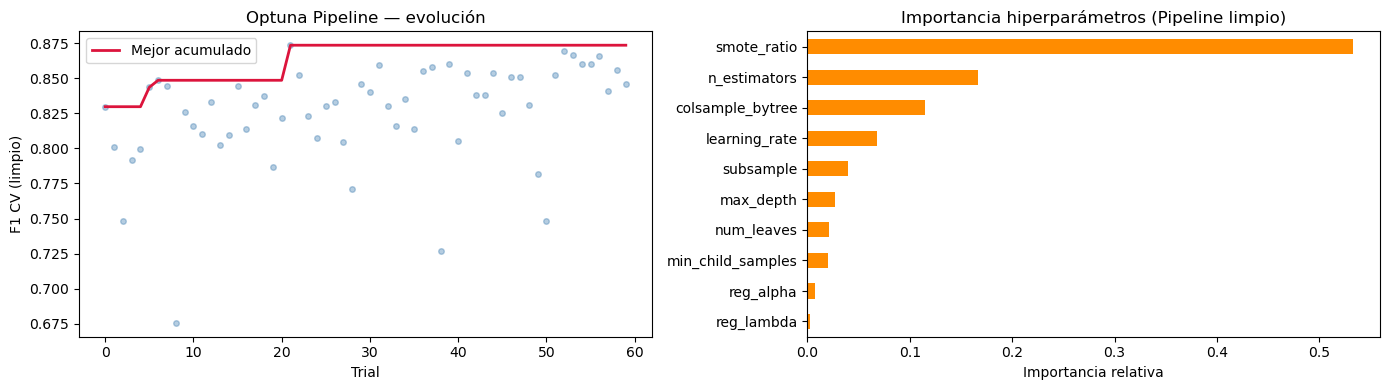

In [17]:
# Importancia hiperparámetros (incluyendo smote_ratio)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study_clean.trials_dataframe()
ax = axes[0]
ax.plot(trials_df['number'], trials_df['value'], 'o', alpha=0.4, color='steelblue', ms=4)
ax.plot(trials_df['number'], trials_df['value'].cummax(),
        color='crimson', lw=2, label='Mejor acumulado')
ax.set_xlabel('Trial'); ax.set_ylabel('F1 CV (limpio)')
ax.set_title('Optuna Pipeline — evolución')
ax.legend()

imp_clean = optuna.importance.get_param_importances(study_clean)
ax = axes[1]
pd.Series(imp_clean).sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Importancia hiperparámetros (Pipeline limpio)')
ax.set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()


## 12. Comparativa final global


                          Precision  Recall      F1  ROC-AUC  Umbral
Baseline LGBM                0.7250  0.8529  0.7838   0.9734  0.0465
RandomizedSearch             0.8788  0.8529  0.8657   0.9808  0.7550
Optuna Pipeline (limpio)     0.8923  0.8529  0.8722   0.9822  0.4672


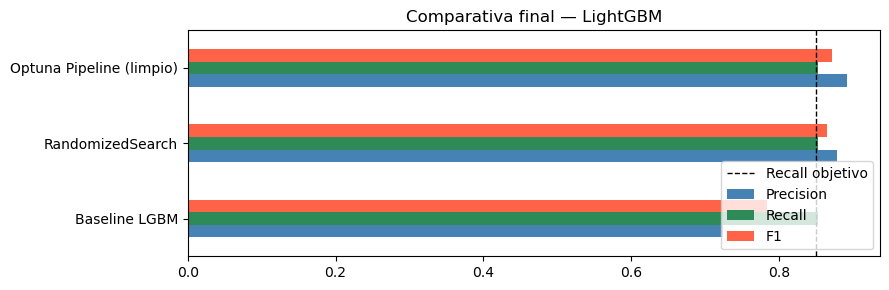

In [18]:
def eval_model(y_true, y_prob, min_recall=0.85):
    prec_c, rec_c, thr_c = precision_recall_curve(y_true, y_prob)
    f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
    mask = rec_c[:-1] >= min_recall
    idx = np.argmax(f1_c * mask) if mask.any() else np.argmax(f1_c)
    thr = thr_c[idx]
    y_pred = (y_prob >= thr).astype(int)
    return {
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
        'Umbral':    round(thr, 4),
    }

comparativa = {
    'Baseline LGBM':             eval_model(y_test, lgbm_base.predict_proba(X_test)[:, 1]),
    'RandomizedSearch':          eval_model(y_test, lgbm_tuned.predict_proba(X_test)[:, 1]),
    'Optuna Pipeline (limpio)':  eval_model(y_test, y_prob_clean),
}

df_final = pd.DataFrame(comparativa).T
print(df_final.to_string())

fig, ax = plt.subplots(figsize=(9, 3))
df_final[['Precision', 'Recall', 'F1']].plot(kind='barh', ax=ax,
    color=['steelblue', 'seagreen', 'tomato'])
ax.axvline(0.85, color='black', ls='--', lw=1, label='Recall objetivo')
ax.set_title('Comparativa final — LightGBM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [19]:
# Guardar modelo ganador
models['lgbm_final']           = lgbm_clean
models['lgbm_final_threshold'] = thr_clean
models['lgbm_final_smote']     = best['smote_ratio']

with open('../data/processed/models.pkl', 'wb') as f:
    pickle.dump(models, f)

print('Modelos guardados:', list(models.keys()))
print(f'Umbral final: {thr_clean:.4f} | SMOTE ratio: {best["smote_ratio"]:.3f}')


Modelos guardados: ['lr', 'rf', 'svm', 'xgb', 'lgbm', 'rf_cnc', 'lgbm_tuned', 'lgbm_threshold', 'lgbm_optuna', 'lgbm_optuna_threshold', 'lgbm_final', 'lgbm_final_threshold', 'lgbm_final_smote', 'stacking', 'stacking_threshold', 'stacking_best', 'stacking_best_threshold', 'rf_tuned', 'svm_tuned', 'scaler', 'stacking_wear_ratio', 'stacking_wear_ratio_threshold', 'scaler_wear_ratio', 'feature_cols_wear_ratio']
Umbral final: 0.4672 | SMOTE ratio: 0.137
